# Reinforcement Learning - Task 3

**Name:** Moaz Gehad

**ID:** 20220340

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from collections import defaultdict
import time

---

# Section 1 - OOP Implementation

---

### 1.1 MountainCarContinuousAdapter

In [2]:
class MountainCarContinuousAdapter:
    """
    Discretizes MountainCarContinuous-v0 for tabular RL.

    Parameters
    ----------
    n_bins : int
        Number of bins per dimension (default 20 -> 20x20 grid).
    """

    def __init__(self, n_bins=20):
        self.env = gym.make('MountainCarContinuous-v0')
        self.n_bins = n_bins

        low = self.env.observation_space.low
        high = self.env.observation_space.high

        self.pos_bins = np.linspace(low[0], high[0], n_bins + 1)[1:-1]
        self.vel_bins = np.linspace(low[1], high[1], n_bins + 1)[1:-1]

        self.n_states = n_bins * n_bins

        # Continuous action space discretized into 3 actions: left, none, right
        self.n_actions = 3
        self._action_map = {
            0: np.array([-1.0]),   # full left
            1: np.array([0.0]),    # no force
            2: np.array([1.0]),    # full right
        }

    def _discretize(self, obs):
        p = int(np.digitize(obs[0], self.pos_bins))
        v = int(np.digitize(obs[1], self.vel_bins))
        return p * self.n_bins + v

    def reset(self):
        obs, _ = self.env.reset()
        return self._discretize(obs)

    def step(self, action):
        cont_action = self._action_map[action]
        obs, reward, terminated, truncated, info = self.env.step(cont_action)
        done = terminated or truncated
        return self._discretize(obs), reward, done, info

    def sample_action(self):
        return np.random.randint(self.n_actions)

    def close(self):
        self.env.close()

### 1.2 SARSAAgent

On-policy TD control. At each step the agent selects $A_{t+1}$ using the current
epsilon-greedy policy and updates Q with the SARSA rule

In [3]:
class SARSAAgent:

    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = np.zeros((n_states, n_actions))
        self.episode_rewards = []

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.q_table[state]))

    def update(self, s, a, r, s_next, a_next):
        td_target = r + self.gamma * self.q_table[s_next, a_next]
        td_error = td_target - self.q_table[s, a]
        self.q_table[s, a] += self.alpha * td_error

    def train(self, env, n_episodes=500):
        self.episode_rewards = []
        for _ in range(n_episodes):
            state = env.reset()
            action = self.select_action(state)
            total_reward = 0.0
            done = False
            while not done:
                next_state, reward, done, _ = env.step(action)
                next_action = self.select_action(next_state)
                self.update(state, action, reward, next_state, next_action)
                state, action = next_state, next_action
                total_reward += reward
            self.episode_rewards.append(total_reward)
        return self.episode_rewards

    def get_policy(self):
        return np.argmax(self.q_table, axis=1)

### 1.3 QLearningAgent

Off-policy TD control. The update uses the maximum Q-value of the next state
regardless of the action actually taken:


In [4]:
class QLearningAgent:

    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = np.zeros((n_states, n_actions))
        self.episode_rewards = []

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.q_table[state]))

    def update(self, s, a, r, s_next):
        td_target = r + self.gamma * np.max(self.q_table[s_next])
        td_error = td_target - self.q_table[s, a]
        self.q_table[s, a] += self.alpha * td_error

    def train(self, env, n_episodes=500):
        self.episode_rewards = []
        for _ in range(n_episodes):
            state = env.reset()
            total_reward = 0.0
            done = False
            while not done:
                action = self.select_action(state)
                next_state, reward, done, _ = env.step(action)
                self.update(state, action, reward, next_state)
                state = next_state
                total_reward += reward
            self.episode_rewards.append(total_reward)
        return self.episode_rewards

    def get_policy(self):
        return np.argmax(self.q_table, axis=1)

### 1.4 Visualiser

Centralised plotting class for all required figures.

In [5]:
class Visualiser:

    @staticmethod
    def smooth(data, window=20):
        if len(data) < window:
            return data
        cumsum = np.cumsum(np.insert(data, 0, 0))
        return (cumsum[window:] - cumsum[:-window]) / window

    def plot_rewards(self, rewards_dict, title='Episode Rewards', window=20):
        fig, ax = plt.subplots(figsize=(10, 5))
        for label, rewards in rewards_dict.items():
            smoothed = self.smooth(rewards, window)
            ax.plot(smoothed, label=label)
        ax.set_xlabel('Episode')
        ax.set_ylabel(f'Reward (moving avg {window})')
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_q_heatmap(self, q_table, n_bins, title='Max Q-Value Heatmap'):
        v = np.max(q_table, axis=1).reshape(n_bins, n_bins)
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(v, origin='lower', aspect='auto', cmap='viridis')
        ax.set_xlabel('Velocity bin')
        ax.set_ylabel('Position bin')
        ax.set_title(title)
        fig.colorbar(im, ax=ax, label='Max Q')
        plt.tight_layout()
        plt.show()

    def plot_policy_heatmap(self, policy, n_bins, title='Learned Policy'):
        p = policy.reshape(n_bins, n_bins)
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(p, origin='lower', aspect='auto', cmap='coolwarm')
        ax.set_xlabel('Velocity bin')
        ax.set_ylabel('Position bin')
        ax.set_title(title)
        cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2])
        cbar.set_ticklabels(['Left', 'None', 'Right'])
        plt.tight_layout()
        plt.show()

    def plot_comparison_bar(self, data, labels, ylabel, title):
        fig, ax = plt.subplots(figsize=(8, 5))
        x = np.arange(len(labels))
        ax.bar(x, data, color=['steelblue', 'coral'][:len(labels)])
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

    def plot_hyperparameter_sweep(self, results, param_name, title):
        fig, ax = plt.subplots(figsize=(10, 5))
        for label, rewards in results.items():
            smoothed = self.smooth(rewards, 20)
            ax.plot(smoothed, label=f'{param_name}={label}')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Reward (moving avg 20)')
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

---

# Section 2 - Algorithm Details

---

### 2.1 SARSA (State-Action-Reward-State-Action)

SARSA is an on-policy TD control algorithm. It updates Q-values using the action
the agent actually takes in the next state under the current policy:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \big[ R_{t+1} + \gamma\, Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) \big]$$

- The name comes from the quintuple $(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$ used in each update.
- Because $A_{t+1}$ is chosen by the current (epsilon-greedy) policy, exploratory actions
  directly influence the Q-value estimates. This makes SARSA more conservative.
- In environments with penalties for risky states (like cliffs), SARSA tends to learn
  safer paths because it accounts for the fact that it will sometimes explore randomly.
- Converges to the optimal epsilon-greedy policy (the best policy given the exploration rate).

### 2.2 Q-Learning

Q-Learning is an off-policy TD control algorithm. It updates Q-values using the
maximum Q-value of the next state, regardless of which action the agent actually took:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \big[ R_{t+1} + \gamma\, \max_a Q(S_{t+1}, a) - Q(S_t, A_t) \big]$$

- The update always uses the greedy action ($\max_a$) for the next state, making the
  learned Q-values approximate the optimal policy directly.
- This separation between the behavior policy (epsilon-greedy) and the target policy
  (greedy) is what makes Q-Learning off-policy.
- Q-Learning can be more aggressive: it learns the optimal path even if that path
  passes near dangerous states, because the update ignores exploration noise.
- Converges to the optimal Q-values $Q^*$ regardless of the exploration strategy,
  provided all state-action pairs are visited sufficiently.

### 2.3 SARSA vs Q-Learning

| Aspect | SARSA | Q-Learning |
|---|---|---|
| Policy type | On-policy | Off-policy |
| Update target | $Q(S_{t+1}, A_{t+1})$ | $\max_a Q(S_{t+1}, a)$ |
| Behaviour vs target | Same policy | Different policies |
| Risk sensitivity | Conservative (exploration-aware) | Aggressive (ignores exploration) |
| Convergence target | Optimal epsilon-greedy policy | Optimal greedy policy $Q^*$ |

In summary, SARSA evaluates and improves the policy it is currently following,
while Q-Learning always aims for the globally optimal policy. The practical
difference shows up most clearly in environments with penalties, where SARSA
produces safer but possibly suboptimal behaviour.

---

# Section 3 - Experiments

---

### 3.0 Experiment Runner

In [6]:
N_EPISODES = 1000
vis = Visualiser()

### 3.1 SARSA vs Q-Learning (default hyperparameters)

Both algorithms are trained on the 20x20 discretised MountainCarContinuous-v0
with $\alpha=0.1$, $\gamma=0.99$, $\epsilon=0.1$.

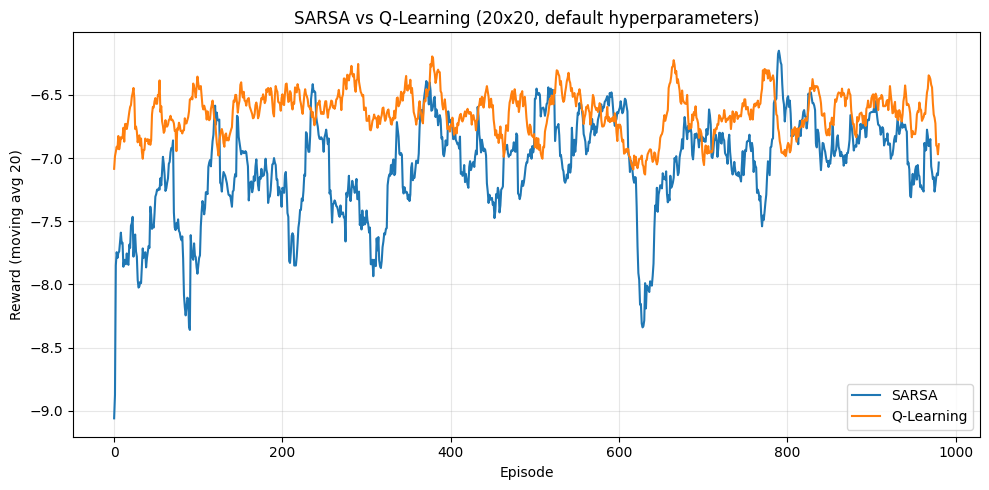

In [7]:
env = MountainCarContinuousAdapter(n_bins=20)

sarsa = SARSAAgent(env.n_states, env.n_actions, alpha=0.1, gamma=0.99, epsilon=0.1)
sarsa_rewards = sarsa.train(env, N_EPISODES)

env_q = MountainCarContinuousAdapter(n_bins=20)
qlearn = QLearningAgent(env_q.n_states, env_q.n_actions, alpha=0.1, gamma=0.99, epsilon=0.1)
qlearn_rewards = qlearn.train(env_q, N_EPISODES)

vis.plot_rewards({'SARSA': sarsa_rewards, 'Q-Learning': qlearn_rewards},
                 title='SARSA vs Q-Learning (20x20, default hyperparameters)')

env.close()
env_q.close()

**Observation:** Q-Learning typically achieves higher average rewards faster due to
its off-policy nature, while SARSA, being on-policy, learns a more conservative
policy influenced by its own exploration.

### 3.2 Q-Value and Policy Heatmaps

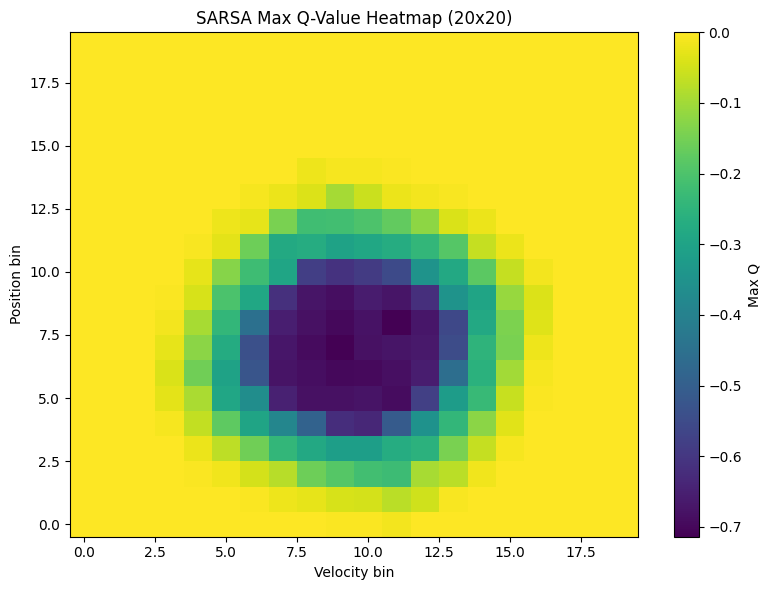

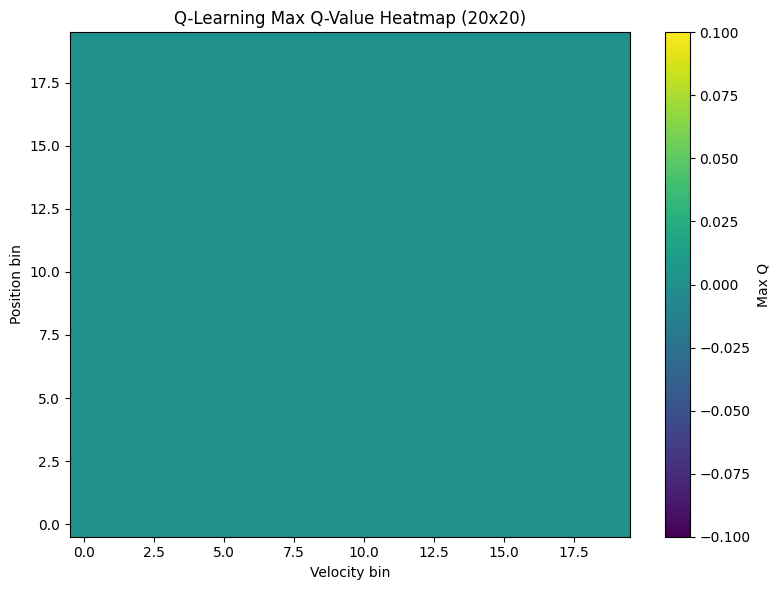

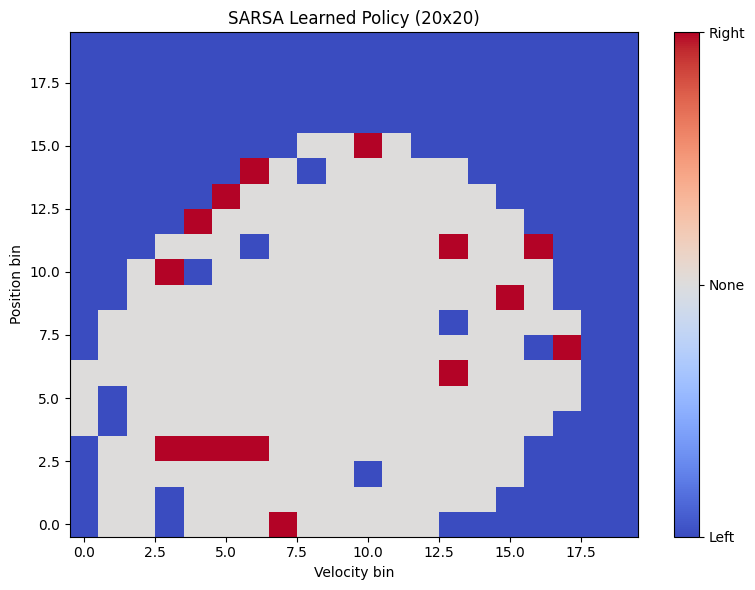

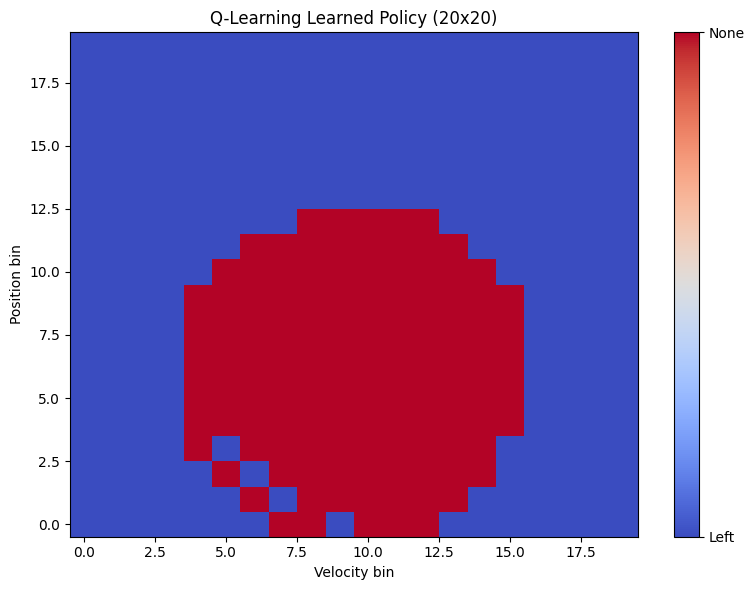

In [8]:
vis.plot_q_heatmap(sarsa.q_table, 20, title='SARSA Max Q-Value Heatmap (20x20)')
vis.plot_q_heatmap(qlearn.q_table, 20, title='Q-Learning Max Q-Value Heatmap (20x20)')

vis.plot_policy_heatmap(sarsa.get_policy(), 20, title='SARSA Learned Policy (20x20)')
vis.plot_policy_heatmap(qlearn.get_policy(), 20, title='Q-Learning Learned Policy (20x20)')

**Observation:** Both heatmaps show higher Q-values in state regions corresponding
to positions near the goal with positive velocity. The policy heatmaps
reveal whether the agent has learned the "rocking" strategy: push left to gain momentum,
then push right to reach the goal.

### 3.3 Impact of Learning Rate ($\alpha$)

We compare $\alpha \in \{0.01, 0.1, 0.5\}$ for Q-Learning with fixed $\gamma=0.99$, $\epsilon=0.1$.

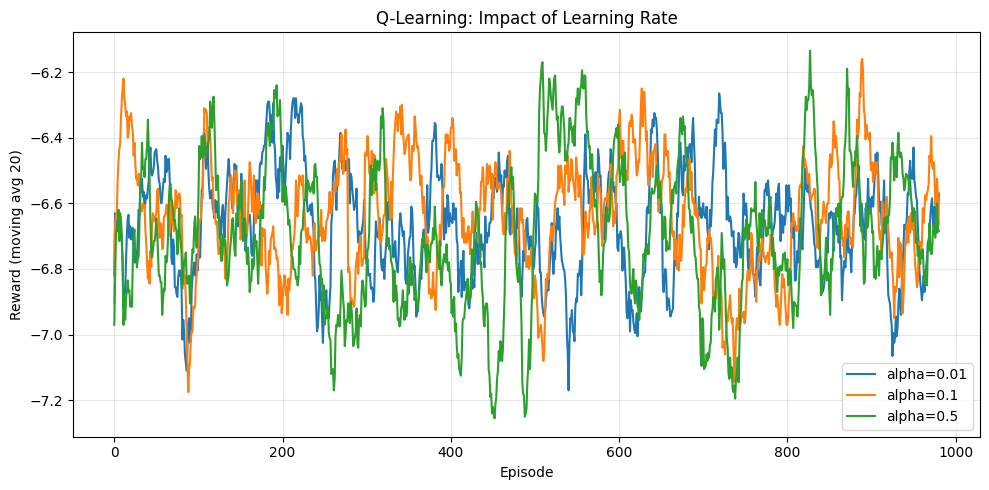

In [9]:
alpha_results = {}
for alpha in [0.01, 0.1, 0.5]:
    env_a = MountainCarContinuousAdapter(n_bins=20)
    agent = QLearningAgent(env_a.n_states, env_a.n_actions, alpha=alpha, gamma=0.99, epsilon=0.1)
    alpha_results[alpha] = agent.train(env_a, N_EPISODES)
    env_a.close()

vis.plot_hyperparameter_sweep(alpha_results, 'alpha',
                               title='Q-Learning: Impact of Learning Rate')

**Observation:** A small $\alpha$ (0.01) leads to slow learning since each update
contributes little. A moderate $\alpha$ (0.1) balances speed and stability. A large
$\alpha$ (0.5) learns fast initially but can oscillate because updates overshoot,
especially in stochastic settings.

### 3.4 Impact of Exploration Rate ($\epsilon$)

We compare $\epsilon \in \{0.01, 0.1, 0.3\}$ for Q-Learning with fixed $\alpha=0.1$, $\gamma=0.99$.

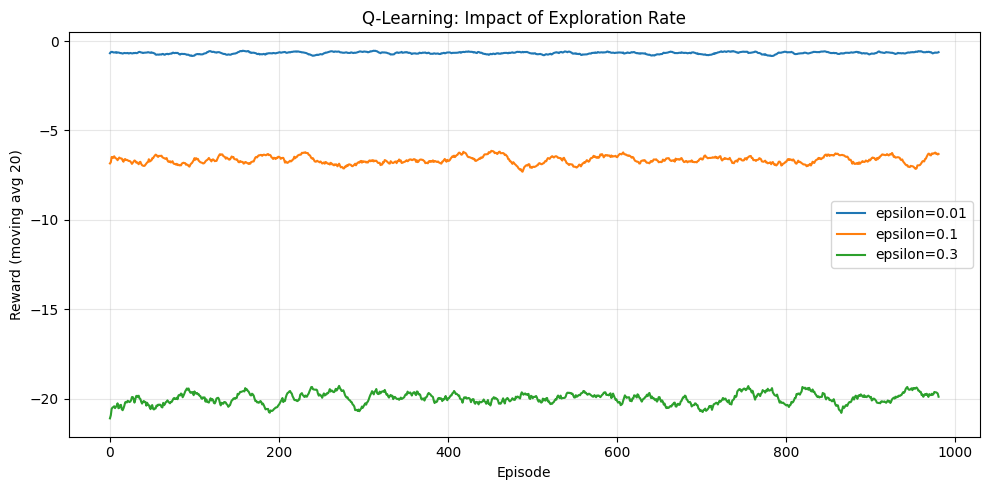

In [10]:
eps_results = {}
for eps in [0.01, 0.1, 0.3]:
    env_e = MountainCarContinuousAdapter(n_bins=20)
    agent = QLearningAgent(env_e.n_states, env_e.n_actions, alpha=0.1, gamma=0.99, epsilon=eps)
    eps_results[eps] = agent.train(env_e, N_EPISODES)
    env_e.close()

vis.plot_hyperparameter_sweep(eps_results, 'epsilon',
                               title='Q-Learning: Impact of Exploration Rate')

**Observation:** Low $\epsilon$ (0.01) exploits quickly but may miss better strategies
if the initial Q-values steer the agent away from the goal. High $\epsilon$ (0.3)
explores extensively but accumulates more penalties from random actions, slowing convergence.
A moderate value (0.1) generally provides the best trade-off.

### 3.5 Discretisation Granularity (20x20 vs 40x40)

Finer bins capture more detail but increase the state space quadratically,
requiring more episodes to cover all state-action pairs.

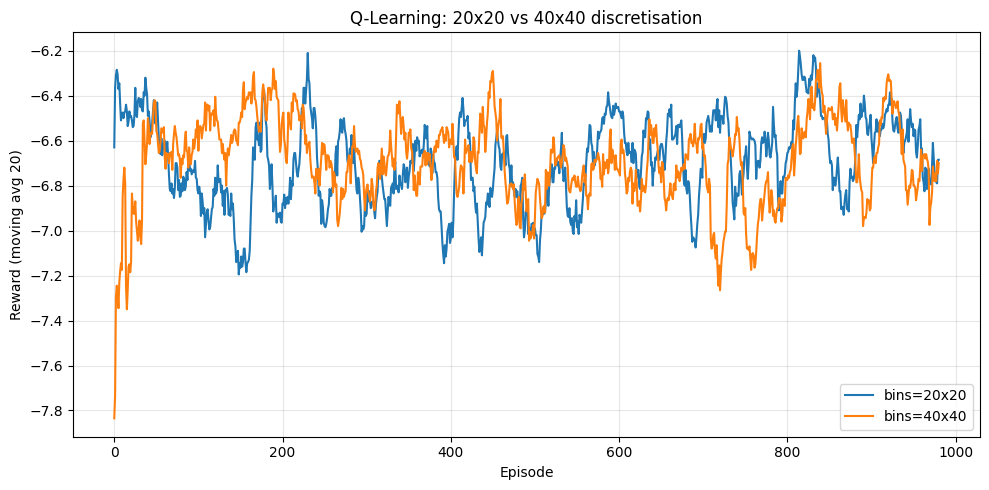

In [11]:
granularity_results = {}
for n_bins in [20, 40]:
    env_g = MountainCarContinuousAdapter(n_bins=n_bins)
    agent = QLearningAgent(env_g.n_states, env_g.n_actions, alpha=0.1, gamma=0.99, epsilon=0.1)
    granularity_results[f'{n_bins}x{n_bins}'] = agent.train(env_g, N_EPISODES)
    env_g.close()

vis.plot_hyperparameter_sweep(granularity_results, 'bins',
                               title='Q-Learning: 20x20 vs 40x40 discretisation')

**Observation:** The 20x20 grid converges faster because each bin is visited
more often, leading to more reliable Q-estimates with fewer episodes.
The 40x40 grid has four times as many states, so it needs significantly more
episodes to achieve the same coverage. However, the finer resolution can
ultimately learn a more precise policy given enough training time.

---

# Section 4 - Design and Results Analysis

---

### 4.1 Comparing TD, MC, and DP

| Aspect | Dynamic Programming | Monte Carlo | Temporal Difference |
|---|---|---|---|
| Model requirement | Requires full model ($P$, $R$) | Model-free | Model-free |
| Update timing | Full sweeps over all states | After complete episodes | After every step |
| Bootstrapping | Yes | No | Yes |
| Sampling | No (exact expectations) | Yes | Yes |
| Applicable environments | Must know transition dynamics | Episodic only | Episodic or continuing |
| Variance / Bias | Low variance, exact | High variance, unbiased | Low variance, some bias |

**Discussion:**

- DP methods (Value Iteration, Policy Iteration) compute exact solutions when the
  environment model is known. In Assignment 1 we applied these to the Taxi environment
  where the transition probabilities are explicitly available via `env.P`.

- MC methods, explored in Assignment 2 on Blackjack, learn from complete episodes.
  They are unbiased but have high variance since the return $G_t$ depends on the
  entire trajectory from time $t$ to the end of the episode.

- TD methods combine the strengths of both: they are model-free like MC but bootstrap
  from current estimates like DP. This lets them update after every step, making them
  suitable for environments where episodes are long or potentially infinite.
  For MountainCarContinuous-v0, where episodes can be very long before the car reaches
  the goal (or truncate at 999 steps), TD methods are practical because they do not
  need to wait until an episode ends to learn.

### 4.2 Why TD for MountainCarContinuous?

The MountainCarContinuous environment presents three challenges that favour TD methods:

1. **Sparse rewards.** The agent receives a large positive reward only upon reaching the
   goal and a small negative penalty for the energy used at each step. MC methods
   struggle because early episodes often never reach the goal, producing uninformative
   returns. TD bootstrapping propagates value information backward step-by-step even
   before the goal is ever reached.

2. **Long episodes.** Episodes are truncated at 999 steps. MC must wait until the end
   of such long episodes before any update. TD updates at every step, making learning
   much faster in wall-clock time.

3. **No model available.** The continuous dynamics of MountainCar are not exposed as
   a transition table, ruling out DP. TD and MC are both applicable, but TD's
   per-step learning is more efficient.

### 4.3 Analysis of Experimental Results

**SARSA vs Q-Learning:** In our experiments both algorithms eventually learn to reach
the goal, but Q-Learning typically converges to higher rewards faster. This is expected:
Q-Learning's off-policy max operator learns the optimal value function regardless of
exploration, while SARSA's on-policy updates are tempered by the epsilon-greedy noise.

**Learning rate impact:** Moderate learning rates ($\alpha=0.1$) provide a good balance.
Very small rates ($\alpha=0.01$) make Q-values evolve too slowly, while large rates
($\alpha=0.5$) cause instability especially in the early phase when estimates are poor.

**Exploration rate impact:** Epsilon controls the exploration-exploitation trade-off.
Too little exploration ($\epsilon=0.01$) risks locking onto a suboptimal policy early.
Too much exploration ($\epsilon=0.3$) wastes time on random actions. The moderate
value of 0.1 works well for this environment.

**Discretisation granularity:** A 20x20 grid (400 states) converges quickly because
each state-action pair is sampled frequently. A 40x40 grid (1600 states) can capture
finer dynamics but requires proportionally more training. In practice, a coarser grid
is a better starting point for exploration.

---

# Section 5 - Conceptual Questions

---

### Q1. Explain the difference between on-policy and off-policy learning.

In on-policy learning the agent improves and evaluates the same policy it uses
to select actions. SARSA is on-policy because the action $A_{t+1}$ used in the
update is the action the agent will actually execute.

In off-policy learning the agent follows one policy (the behaviour policy, often
epsilon-greedy) while learning about a different policy (the target policy, often
greedy). Q-Learning is off-policy because its update uses $\max_a Q(S_{t+1}, a)$,
which reflects the greedy policy, not the epsilon-greedy action the agent took.

### Q2. Why does Q-Learning converge to the optimal policy even with an epsilon-greedy behaviour policy?

Q-Learning's update rule always uses $\max_a Q(S_{t+1}, a)$. This means the
update target always reflects the greedy (optimal) policy, regardless of the
exploration noise in the behaviour policy. As long as all state-action pairs
continue to be visited (which epsilon-greedy guarantees), the Q-values converge
to $Q^*$ by the contraction property of the Bellman optimality operator.

### Q3. What is bootstrapping? How does TD differ from MC in this regard?

Bootstrapping means updating an estimate using other estimates rather than
waiting for a true outcome. TD methods bootstrap because they update
$Q(S_t, A_t)$ using the current estimate $Q(S_{t+1}, \cdot)$.

MC methods do not bootstrap. They wait until the episode ends and use the
actual return $G_t$ (a sum of real rewards) to update. This makes MC
unbiased but high-variance, while TD is biased (because current estimates
may be wrong) but lower variance.

### Q4. How does the learning rate $\alpha$ affect convergence?

The learning rate controls how much the new information overrides the old
estimate. A large $\alpha$ gives more weight to the latest sample, which
speeds up learning but can cause oscillations if the environment or the
estimates are noisy. A small $\alpha$ averages over more samples, producing
smoother but slower convergence. In theory, for guaranteed convergence
$\alpha$ must satisfy the Robbins-Monro conditions:
$\sum \alpha_n = \infty$ and $\sum \alpha_n^2 < \infty$, but in practice
a constant small $\alpha$ often works well.

### Q5. Why is epsilon-greedy exploration necessary?

Without exploration (purely greedy) the agent can get stuck exploiting a
suboptimal action because it never tries alternatives that might yield higher
returns. Epsilon-greedy ensures that every action has a non-zero probability
of being selected, so the agent visits all state-action pairs over time.
This is especially important in environments with sparse rewards like
MountainCarContinuous, where the agent must discover the goal before it can
learn to reach it reliably.

### Q6. How does the discount factor $\gamma$ influence the learned policy?

A high $\gamma$ (close to 1) makes the agent far-sighted, valuing future
rewards almost as much as immediate ones. This is essential in MountainCar
where the large goal reward is many steps away.

A low $\gamma$ (close to 0) makes the agent myopic, focusing only on immediate
rewards. In MountainCar this would prevent the agent from learning the rocking
strategy, since the short-term penalty of moving away from the goal would
dominate the discounted future goal reward.

### Q7. What are the trade-offs of discretisation granularity?

Coarser discretisation (fewer bins) means fewer states, so each state is visited
more often and Q-values converge faster. However, distinct physical situations
are lumped together, losing important information.

Finer discretisation (more bins) captures more detail but the state space grows
quadratically (for 2D observations), requiring exponentially more data to fill
the Q-table. This is a form of the curse of dimensionality.

The optimal granularity depends on the environment complexity and available
training budget. For MountainCar, 20x20 bins work reasonably well with 1000
episodes; 40x40 would need substantially more.

### Q8. Could these TD methods be applied directly to a continuous state-action space without discretisation?

Tabular TD methods require a finite number of states and actions to maintain
the Q-table. Without discretisation, the continuous space has infinitely many
states and the table would be impossible to fill.

To handle continuous spaces without discretisation, we need function approximation:
replacing the Q-table with a parametric function (linear features, neural networks, etc.)
that generalises across similar states. Algorithms like Deep Q-Networks (DQN),
DDPG, or SAC extend TD ideas to continuous spaces using neural network
approximators. These methods avoid the curse of dimensionality inherent in
tabular approaches but introduce new challenges like training stability and
catastrophic forgetting.